In [1]:
#imports

import pandas as pd
import numpy as np
from numpy import random
from numpy import linalg as LA
import seaborn as sns
import snakeviz
from scipy.special import expit, logit, softmax
import line_profiler
from pathlib import Path
import os

seed = 42

# **Plan**

- train 3 models:
    - A benchmark logistic regression with probability output (retrieve from logit)
    - MLP with standard probabilistic MSE (Brier score)
    - MLP with weighted probabilistic MSE (weighted brier score)
- Evaluate perofrmance compared to benchmark

# **Load data**

In [8]:
#load data

path = Path.cwd().parent
data_path = path / "data"

df_X = pd.read_csv(data_path / "X_trn.csv")
df_Y = pd.read_csv(data_path / "Y_trn.csv")

print(df_X.shape)
print(df_Y.shape)
print(df_Y.value_counts(normalize=True))

(25000, 23)
(25000, 1)
Y
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [3]:
#train-validation split
rng = random.default_rng(seed)

y = df_Y["Y"].to_numpy()
n_val = int(np.ceil(0.30 * len(y)))
classes, counts = np.unique(y, return_counts=True)

expected = counts * n_val / len(y)
val_counts = np.floor(expected).astype(int)

for i in np.argsort(-(expected - val_counts))[:n_val - val_counts.sum()]:
    val_counts[i] += 1

val_indices = []
for cls, count in zip(classes, val_counts):
    indices = np.flatnonzero(y == cls)
    val_indices.extend(rng.choice(indices, size=count, replace=False))

val_indices = np.array(val_indices)
train_mask = np.ones(len(y), dtype=bool)
train_mask[val_indices] = False

X_train = df_X.iloc[train_mask]
X_val = df_X.iloc[val_indices]
Y_train = df_Y.iloc[train_mask]
Y_val = df_Y.iloc[val_indices]
print(X_train.shape, Y_train.shape)
print(X_val.shape, Y_val.shape)
print(Y_val.value_counts(normalize=True)) #the validation set is stratified

(17500, 23) (17500, 1)
(7500, 23) (7500, 1)
Y
0    0.7788
1    0.2212
Name: proportion, dtype: float64


# **Data Exploration**

In [4]:
df_X.describe()

,X01,X02,X03,X04,X05,X06,X07,X08,X09,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
count,25000.00000,2.500000e+04,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,2.500000e+04,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,2.500000e+04,2.500000e+04,25000.000000,25000.000000,25000.000000,25000.000000
mean,5291.73684,4.718632e+04,-19.047160,1.600640,35.47872,-18.309920,-10.490080,5652.883040,5.870609e+03,40517.481720,...,4867.042880,-8.526800,1.551400,-15.524800,4.934852e+04,1.674288e+05,5247.070200,4832.123000,4.841600,39069.430360
std,18016.36868,6.991226e+04,3.368565,0.489777,9.25810,7.026897,3.600414,15850.257553,2.246669e+04,61184.642714,...,15974.451874,2.276552,0.522235,4.789929,7.170667e+04,1.307733e+05,17226.376558,15408.337477,4.621247,59809.027104
min,0.00000,-1.644070e+05,-25.000000,1.000000,21.00000,-29.000000,-16.000000,0.000000,0.000000e+00,-80654.000000,...,0.000000,-12.000000,0.000000,-23.000000,-7.187600e+04,8.819000e+03,0.000000,0.000000,-2.000000,-309891.000000
25%,120.00000,2.737000e+03,-22.000000,1.000000,28.00000,-23.000000,-13.000000,965.000000,8.600000e+02,1801.500000,...,291.000000,-10.000000,1.000000,-19.000000,2.999750e+03,5.386775e+04,412.000000,274.000000,2.000000,1276.500000
50%,1502.00000,2.026500e+04,-19.000000,2.000000,34.00000,-17.000000,-10.000000,2148.000000,2.083000e+03,18020.000000,...,1510.000000,-8.000000,2.000000,-15.000000,2.137300e+04,1.393640e+05,1826.000000,1546.000000,6.000000,17147.500000
75%,4093.00000,6.038675e+04,-19.000000,2.000000,41.00000,-17.000000,-10.000000,5111.250000,5.040000e+03,50993.250000,...,4086.000000,-8.000000,2.000000,-15.000000,6.390675e+04,2.389145e+05,4516.250000,4121.250000,6.000000,49882.750000
max,535570.00000,1.749017e+06,5.000000,2.000000,78.00000,31.000000,14.000000,487371.000000,1.678842e+06,896445.000000,...,577660.000000,8.000000,3.000000,17.000000,1.087738e+06,1.017656e+06,895321.000000,442282.000000,38.000000,859923.000000


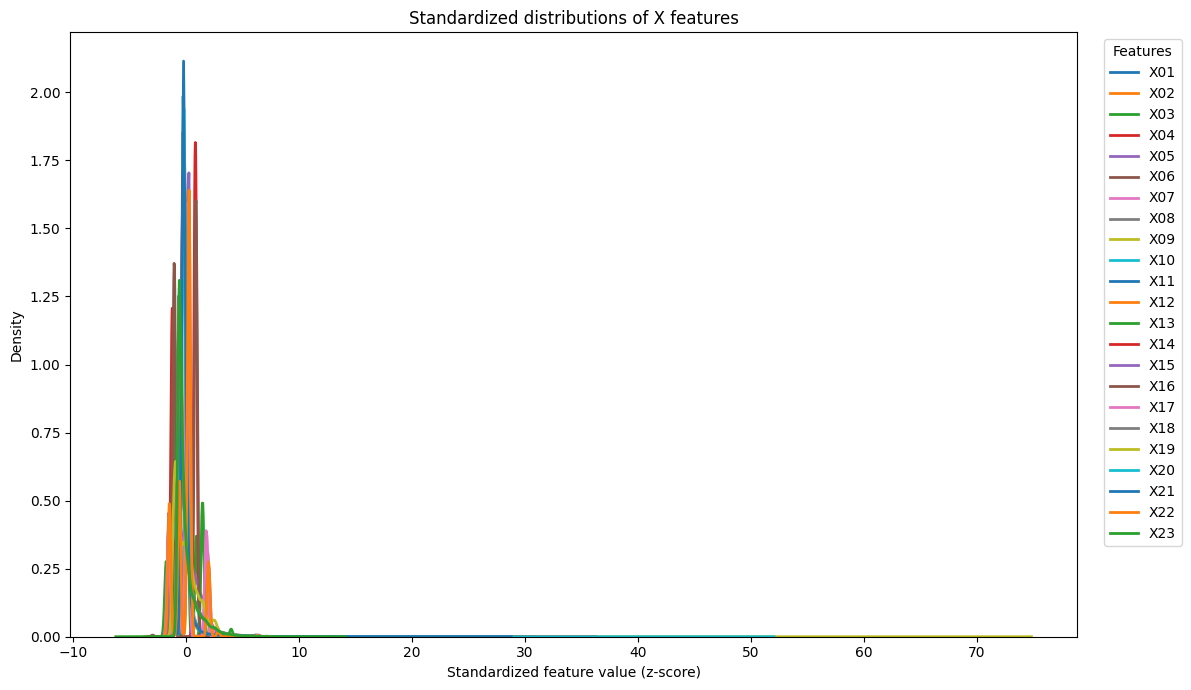

In [5]:
# overlapping standardized feature distributions
import matplotlib.pyplot as plt

X_standardized = (df_X - df_X.mean()) / df_X.std(ddof=0)

plt.figure(figsize=(12, 7))
for column in X_standardized.columns:
    sns.kdeplot(
        X_standardized[column].dropna(),
        label=column,
        fill=False,
        linewidth=2,
    )

plt.title("Standardized distributions of X features")
plt.xlabel("Standardized feature value (z-score)")
plt.ylabel("Density")
plt.legend(title="Features", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# **Logistic regression** 

# **Neural Network**

In [ ]:
#activation function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

#feedforward process for a 3-layer neural network, 2 relu activations and 1 sigmoid activation for the output layer
def feedforward(X, w1, w2, w3):
    a1 = np.dot(X, w1)
    z1 = relu(a1)
    a2 = np.dot(z1, w2)
    z2 = relu(a2)
    a3 = np.dot(z2, w3)
    z3 = sigmoid(a3)
    return z3

#initialize weights
def initialize_weights(input_size):
    w1 = np.random.randn(input_size, 10)   #input layer to first hidden layer 23 features to 10 neurons
    w2 = np.random.randn(10, 10)    #10 to 10 neurons
    w3 = np.random.randn(10, 1)      #10 neurons to 1 output neuron
    return w1, w2, w3

def brier_loss(y_true, y_pred):
    #brier loss
    return np.mean((y_pred - y_true) ** 2)

def weighted_brier_loss(y_true, y_pred, weights):
    #weighted brier loss
    return np.mean(weights * (y_pred - y_true) ** 2)

# backpropogation
def backpropogation(x, y, w1, w2, w3, alpha):
    y = np.asarray(y).reshape(-1, 1)
    n_samples = x.shape[0]  

    #forward pass
    a1 = np.dot(x, w1)
    z1 = relu(a1)
    a2 = np.dot(z1, w2)
    z2 = relu(a2)
    a3 = np.dot(z2, w3)
    z3 = sigmoid(a3)

    #loss in prediction
    loss = brier_loss(y, z3)

    # Gradients of the Brier loss, sigmoid, and ReLU activations
    d3 = (2 / n_samples) * (z3 - y) * z3 * (1 - z3)
    d2 = (d3 @ w3.T) * (a2 > 0)
    d1 = (d2 @ w2.T) * (a1 > 0)

    # Gradients with respect to the weights
    dw3 = z2.T @ d3
    dw2 = z1.T @ d2
    dw1 = x.T @ d1

    # Gradient-descent update
    w1 = w1 - alpha * dw1
    w2 = w2 - alpha * dw2
    w3 = w3 - alpha * dw3

    return w1, w2, w3, loss